In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
def load_and_merge_files(human_file, model_files_dict, join_col='Word'):
    """
    Reads and merges files, supporting any number of model files.
    Automatically converts the join column to lowercase and strips whitespace to improve matching rates.
    """
    print(f"Reading Human file: {human_file}")
    try:
        df_human = pd.read_excel(human_file)
    except Exception as e:
        print(f"Failed to read Human file: {e}")
        return None
        
    # Unify join_col in Human file
    col = next((c for c in df_human.columns if c.lower() == join_col.lower()), None)
    if col:
        df_human.rename(columns={col: join_col}, inplace=True)
        # === Added: Standardize join column (lowercase + strip) ===
        df_human[join_col] = df_human[join_col].astype(str).str.strip().str.lower()
    else:
        print(f"Warning: '{join_col}' column not found in Human file. Available columns: {df_human.columns.tolist()}")
        return None
        
    # Rename Human columns: {col}_human
    df_human.columns = [c if c == join_col else f"{c}_human" for c in df_human.columns]
    
    df_merged = df_human
    print(f"Human data loaded, total {len(df_merged)} rows. Example: {df_merged[join_col].head(3).tolist()}")
    
    for model_name, file_path in model_files_dict.items():
        print(f"Reading Model ({model_name}): {file_path}")
        try:
            df_m = pd.read_excel(file_path)
        except Exception as e:
            print(f"Failed to read {model_name}: {e}")
            return None
            
        # Unify join_col in Model file
        col = next((c for c in df_m.columns if c.lower() == join_col.lower()), None)
        if col:
            df_m.rename(columns={col: join_col}, inplace=True)
            # === Added: Standardize join column ===
            df_m[join_col] = df_m[join_col].astype(str).str.strip().str.lower()
        else:
            print(f"Warning: '{join_col}' column not found in {model_name} file. Available columns: {df_m.columns.tolist()}")
            return None
            
        # Rename Model columns: {col}_{model_name_lower}
        suffix = model_name.lower().replace(" ", "_")
        df_m.columns = [c if c == join_col else f"{c}_{suffix}" for c in df_m.columns]
        
        # Merge
        before_len = len(df_merged)
        df_merged = df_merged.merge(df_m, on=join_col, how='inner')
        after_len = len(df_merged)
        
        print(f"  -> After merging with {model_name}: {before_len} -> {after_len} rows")
        
        if after_len == 0:
            print(f"  !!! Warning: Merging with {model_name} resulted in empty data.")
            print(f"  Human side word examples: {df_human[join_col].head(5).tolist()}")
            print(f"  Model side word examples: {df_m[join_col].head(5).tolist()}")
            return df_merged # Return empty result early
        
    print(f"Merge complete, final shape: {df_merged.shape}")
    return df_merged

In [3]:
def calculate_similarities(df, human_col_pattern, model_col_patterns, dimensions, model_dim_mapping=None):
    """
    Universal similarity calculation function, supporting any number of models.
    
    Args:
        df: Merged DataFrame
        human_col_pattern: Human data column name pattern, e.g., "{dim}.mean_human"
        model_col_patterns: Dictionary, keys are model names, values are column name patterns.
                            e.g.: {'Base': '{dim}_base', 'FT': '{dim}_ft', 'FT2': '{dim}_ft2'}
        dimensions: List of dimensions
        model_dim_mapping: (Optional) Dictionary to map dimension names to names in model files.
                           e.g.: {'foot_leg': 'foot', 'hand_arm': 'hand'}
    """
    results = []
    
    # Pre-build column name mapping to support case-insensitive matching
    cols_map = {c.lower(): c for c in df.columns}
    
    for dim in dimensions:
        row_result = {'Dimension': dim}
        
        # Get human data column
        human_col = human_col_pattern.format(dim=dim)
        human_col_real = cols_map.get(human_col.lower())
        
        if not human_col_real:
            print(f"Warning: Human data column missing for dimension {dim}. Expected: {human_col}")
            continue
            
        # Iterate through each model
        valid_dim = True
        model_vals_dict = {}

        # Determine dimension name used on model side
        model_dim_name = dim
        if model_dim_mapping and dim in model_dim_mapping:
            model_dim_name = model_dim_mapping[dim]
        
        for model_name, pattern in model_col_patterns.items():
            model_col = pattern.format(dim=model_dim_name)
            model_col_real = cols_map.get(model_col.lower())
            
            if not model_col_real:
                print(f"Warning: Model {model_name} column missing for dimension {dim} (lookup: {model_dim_name}). Expected: {model_col}")
                valid_dim = False
                break
            
            model_vals_dict[model_name] = model_col_real
            
        if not valid_dim:
            continue
            
        # Extract all relevant columns and drop null values
        cols_to_extract = [human_col_real] + list(model_vals_dict.values())
        subset = df[cols_to_extract].dropna()
        
        if len(subset) < 2:
            print(f"Warning: Insufficient valid data for dimension {dim} (n={len(subset)}). Skipping.")
            continue
            
        human_vals = subset[human_col_real]
        
        # Calculate metrics for each model
        for model_name, col_real in model_vals_dict.items():
            model_vals = subset[col_real]
            
            # Spearman
            spear, p_spear = spearmanr(human_vals, model_vals)
            row_result[f'{model_name}_Spearman'] = spear
            row_result[f'{model_name}_Spearman_p'] = p_spear
            
            # Pearson
            pearson, p_pearson = pearsonr(human_vals, model_vals)
            row_result[f'{model_name}_Pearson'] = pearson
            row_result[f'{model_name}_Pearson_p'] = p_pearson
            
            # Cosine
            cos = cosine_similarity(human_vals.values.reshape(1, -1), model_vals.values.reshape(1, -1))[0][0]
            row_result[f'{model_name}_Cosine'] = cos
            
        results.append(row_result)
        
    return pd.DataFrame(results)

# Study1

In [4]:
# ==========================================
# Study 1 Analysis (Lancaster) 
# ==========================================

results_dir = 'results'
file_human = os.path.join(results_dir, '1_test_sensorimotor_random_sample_.xlsx')

model_files = {
    'base_gpt_4o_mini': os.path.join(results_dir, '1_lancaster_base_model.xlsx'),
    'ft_gpt_4o_mini': os.path.join(results_dir, '1_lancaster_ft_model.xlsx'),
}

df_study1 = load_and_merge_files(file_human, model_files, join_col='Word')

if df_study1 is not None:
    dims_study1 = [
        'auditory', 'gustatory', 'haptic', 'interoceptive', 'olfactory', 'visual', 
        'foot_leg', 'hand_arm', 'head', 'mouth', 'torso'
    ]
    
    # 2. Define column name patterns
    # Note: load_and_merge_files automatically adds _{model_name_lower} suffix to column names
    # e.g., Base model -> _base, FT model -> _ft
    
    # Assuming original column name is 'auditory_gpt_base', with suffix it becomes 'auditory_gpt_base_base'
    # We can construct a pattern dictionary
    
    model_patterns = {
        'base_gpt_4o_mini': "{dim}_gpt_base_base_gpt_4o_mini", # Adjust based on actual column names
        'ft_gpt_4o_mini': "{dim}_gpt_ft_ft_gpt_4o_mini"
    }
    
    print("\nCalculating Study 1 similarities...")
    results_study1 = calculate_similarities(
        df_study1,
        human_col_pattern="{dim}.mean_human", 
        model_col_patterns=model_patterns,
        dimensions=dims_study1
    )
    
print("\nStudy 1 Results:")
print(results_study1)   

Reading Human file: results/1_test_sensorimotor_random_sample_.xlsx
Human data loaded, total 1589 rows. Example: ['semirural', 'done', 'toga']
Reading Model (base_gpt_4o_mini): results/1_lancaster_base_model.xlsx
  -> After merging with base_gpt_4o_mini: 1589 -> 1589 rows
Reading Model (ft_gpt_4o_mini): results/1_lancaster_ft_model.xlsx
  -> After merging with ft_gpt_4o_mini: 1589 -> 1589 rows
Merge complete, final shape: (1589, 47)

Calculating Study 1 similarities...

Study 1 Results:
        Dimension  base_gpt_4o_mini_Spearman  base_gpt_4o_mini_Spearman_p  \
0        auditory                   0.225081                 1.066512e-19   
1       gustatory                   0.380245                 7.974364e-56   
2          haptic                   0.414110                 7.138189e-67   
3   interoceptive                   0.430468                 1.101084e-72   
4       olfactory                   0.432701                 1.672282e-73   
5          visual                  -0.022868  

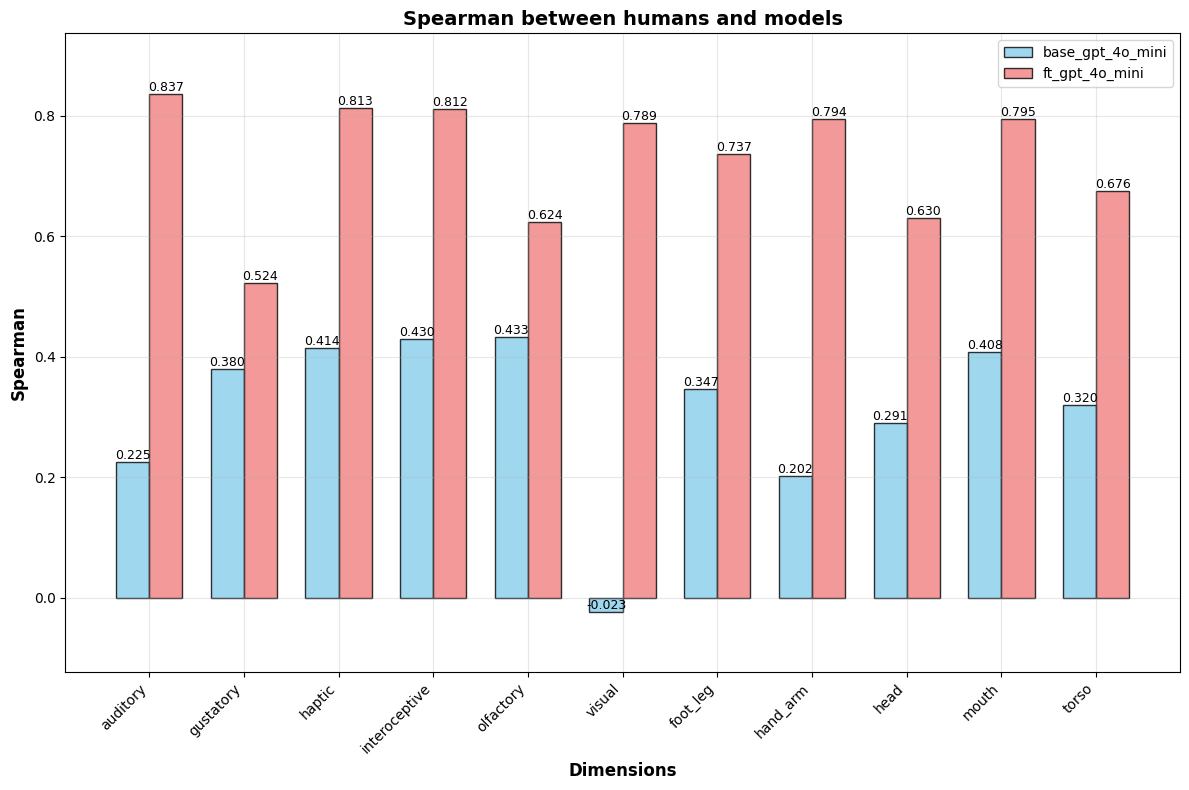

In [5]:
def plot_similarity_comparison(similarity_df, similarity_type='Spearman'):
    """
    Plot similarity comparison bar chart
    
    Parameters:
    similarity_df: DataFrame of similarity results
    similarity_type: Similarity type ('Spearman', 'Pearson', 'Cosine')
    """
    
    base_col = 'base_gpt_4o_mini_'+similarity_type
    ft_col = 'ft_gpt_4o_mini_'+similarity_type
    ylabel = similarity_type
    
    # Prepare plotting data
    dimensions = similarity_df['Dimension'].tolist()
    base_scores = similarity_df[base_col].tolist()
    ft_scores = similarity_df[ft_col].tolist()
    
    # Set up figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set bar positions
    x = np.arange(len(dimensions))
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, base_scores, width, label='base_gpt_4o_mini', 
                   color='skyblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, ft_scores, width, label='ft_gpt_4o_mini', 
                   color='lightcoral', edgecolor='black', alpha=0.8)
    
    # Add value labels
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    
    # Set figure properties
    ax.set_xlabel('Dimensions', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(f'{similarity_type} between humans and models', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(dimensions, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set y-axis range to ensure enough space for labels
    y_min = min(min(base_scores), min(ft_scores))
    y_max = max(max(base_scores), max(ft_scores))
    ax.set_ylim([y_min - 0.1, y_max + 0.1])
    
    plt.tight_layout()
    plt.show()

plot_similarity_comparison(results_study1, similarity_type='Spearman')

# Study2

In [6]:
# ==========================================
# Study 2 Analysis (Cross-lingual)
# ==========================================

results_dir = 'results'

# Define dimensions
dims_study2_en = ['Auditory', 'Gustatory', 'Haptic', 'Olfactory', 'Visual', 'Interoceptive']

# --- Analysis 1: English Context (English Test Set) ---
print("\n" + "="*40)
print("Analyzing English Context (English Test Set)")
print("="*40)

# File paths
file_human_en = os.path.join(results_dir, '2_test_sensorimotor_random_sample.xlsx') # Assuming it contains English data

model_files_en = {
    'base': os.path.join(results_dir, '2_base_model_en_test.xlsx'),
    'en_ft': os.path.join(results_dir, '2_en_model_en_test.xlsx'),
    "dutch_ft": os.path.join(results_dir, '2_dutch_model_en_test.xlsx'),
}

df_study2_en = load_and_merge_files(file_human_en, model_files_en, join_col='Word')

if df_study2_en is not None:
    # Calculate similarity
    # Human: {dim}.mean_human (Assuming Human file structure is similar to Study 1)
    # Base: {dim}_base (Assuming Model file column names are dimension names)
    # FT: {dim}_ft
    
    # Note: If Model file column name is 'Auditory_English_gpt_base', it becomes 'Auditory_English_gpt_base_base' after merge
    # If Model file column name is just 'Auditory', it becomes 'Auditory_base' after merge
   
    model_patterns = {
        'base': "{dim}_English_gpt_base_base", 
        'en_ft': "{dim}_gpt_ft_en_ft",
        'dutch_ft': "{dim}_English_gpt_ft_dutch_ft"
    }

    results_study2_en = calculate_similarities(
        df_study2_en,
        human_col_pattern="{dim}.mean_human", # Or {dim}_English_human_human?
        model_col_patterns=model_patterns,
        dimensions=dims_study2_en
    )

print(results_study2_en)



Analyzing English Context (English Test Set)
Reading Human file: results/2_test_sensorimotor_random_sample.xlsx
Human data loaded, total 1572 rows. Example: ['unwilling', 'endless', 'networking']
Reading Model (base): results/2_base_model_en_test.xlsx
  -> After merging with base: 1572 -> 1465 rows
Reading Model (en_ft): results/2_en_model_en_test.xlsx
  -> After merging with en_ft: 1465 -> 1465 rows
Reading Model (dutch_ft): results/2_dutch_model_en_test.xlsx
  -> After merging with dutch_ft: 1465 -> 1465 rows
Merge complete, final shape: (1465, 76)
       Dimension  base_Spearman  base_Spearman_p  base_Pearson  \
0       Auditory       0.261062     2.978076e-24      0.274665   
1      Gustatory       0.368029     3.274278e-48      0.530956   
2         Haptic       0.433570     3.372050e-68      0.451304   
3      Olfactory       0.448625     2.103002e-73      0.619169   
4         Visual       0.023706     3.645572e-01      0.038185   
5  Interoceptive       0.451788     1.368572e-

In [7]:

# --- Analysis 2: Dutch Context (Dutch Test Set) ---
print("\n" + "="*40)
print("Analyzing Dutch Context (Dutch Test Set)")
print("="*40)

# File paths
file_human_nl = os.path.join(results_dir, '2_test_sensorimotor_random_sample.xlsx') # Assuming it contains Dutch data

model_files_nl = {
    'base': os.path.join(results_dir, '2_base_model_dutch_test.xlsx'),
    'en_ft': os.path.join(results_dir, '2_en_model_dutch_test.xlsx'),
    "dutch_ft": os.path.join(results_dir, '2_dutch_model_dutch_test.xlsx'),
}

df_study2_nl = load_and_merge_files(file_human_nl, model_files_nl, join_col='Woord')

dutch_map = {
        'Auditory': 'Horen', 
        'Gustatory': 'Proeven', 
        'Haptic': 'Voelen',
        'Olfactory': 'Ruiken', 
        'Visual': 'Zien', 
        'Interoceptive': 'Sensaties'
    }

rename_dict = {}
# Get lowercase mapping of existing column names for case-insensitive lookup
cols_lower = {c.lower(): c for c in df_study2_nl.columns}
    
for en_dim, nl_dim in dutch_map.items():
    # Try to find Horen_human (case-insensitive)
    target_key = f"{nl_dim}_human".lower()
    if target_key in cols_lower:
        real_col_name = cols_lower[target_key]
        # Target format must match human_col_pattern="{dim}.mean_human"
        new_col_name = f"{en_dim}_human"
        rename_dict[real_col_name] = new_col_name
            
if rename_dict:
    df_study2_nl.rename(columns=rename_dict, inplace=True)

model_patterns = {
        'base': "{dim}_Dutch_gpt_base_base", 
        'en_ft': "{dim}_dutch_gpt_en_ft_en_ft",
        'dutch_ft': "{dim}_Dutch_gpt_ft_dutch_ft"
    }

results_study2_nl = calculate_similarities(
        df_study2_nl,
        human_col_pattern="{dim}_human", 
        model_col_patterns=model_patterns,
        dimensions=dims_study2_en
    )

print(results_study2_nl)


Analyzing Dutch Context (Dutch Test Set)
Reading Human file: results/2_test_sensorimotor_random_sample.xlsx
Human data loaded, total 1572 rows. Example: ['onwillig', 'eindeloos', 'netwerken']
Reading Model (base): results/2_base_model_dutch_test.xlsx
  -> After merging with base: 1572 -> 1465 rows
Reading Model (en_ft): results/2_en_model_dutch_test.xlsx
  -> After merging with en_ft: 1465 -> 1465 rows
Reading Model (dutch_ft): results/2_dutch_model_dutch_test.xlsx
  -> After merging with dutch_ft: 1465 -> 1465 rows
Merge complete, final shape: (1465, 71)
       Dimension  base_Spearman  base_Spearman_p  base_Pearson  \
0       Auditory       0.237429     3.202895e-20      0.223415   
1      Gustatory       0.237625     2.977429e-20      0.327605   
2         Haptic      -0.101027     1.073024e-04     -0.124034   
3      Olfactory       0.282767     2.454853e-28      0.403414   
4         Visual      -0.010192     6.967116e-01     -0.003920   
5  Interoceptive       0.499147     3.875

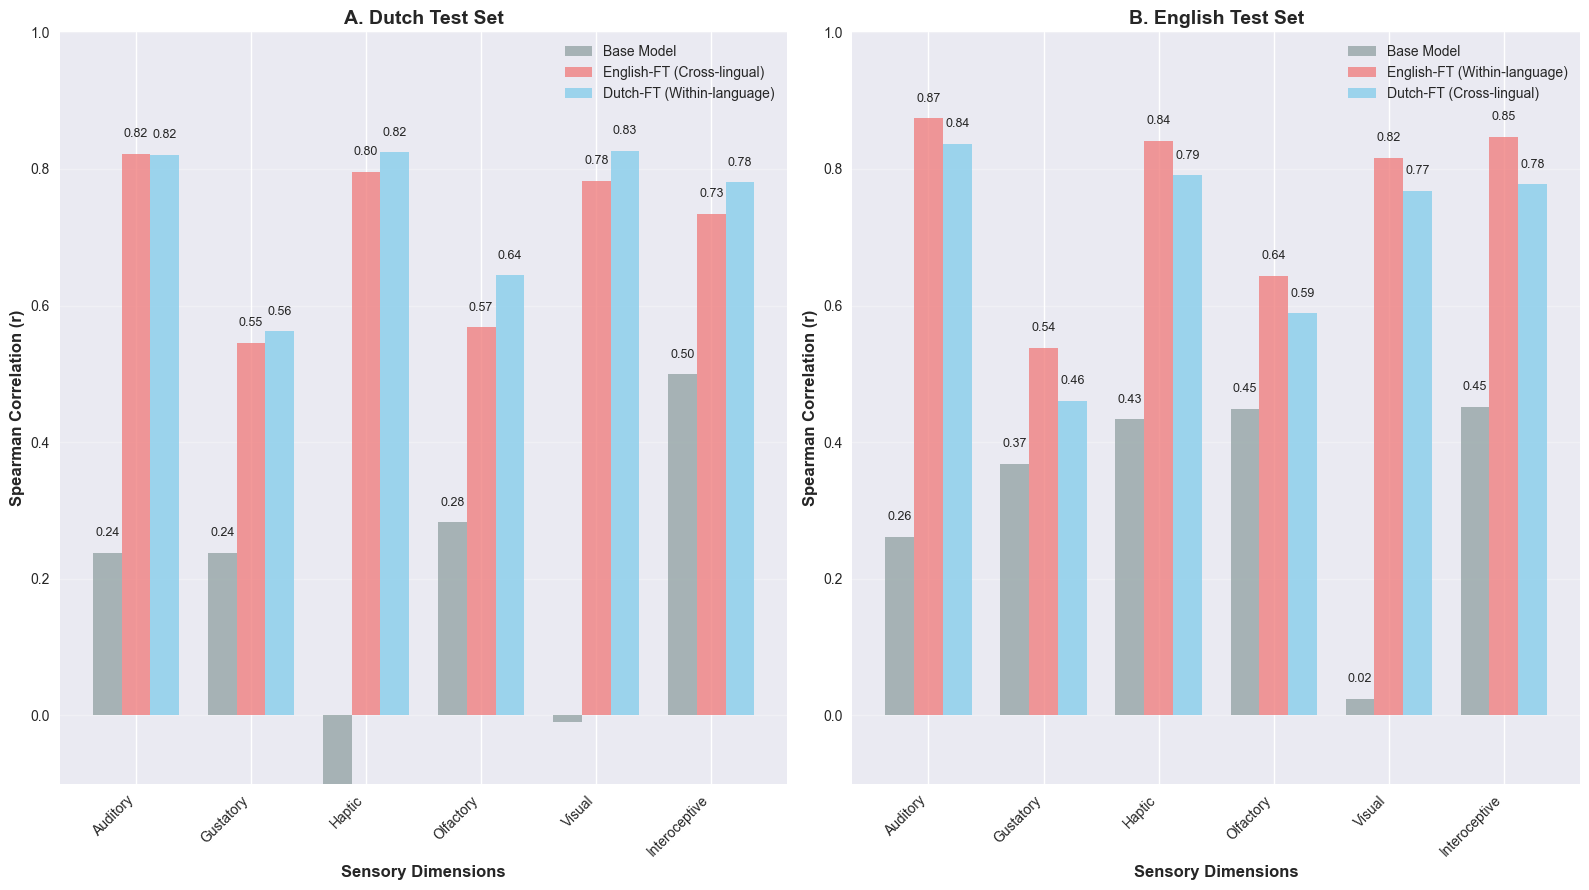

In [ ]:
# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif'] # Changed to standard fonts
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

def plot_cross_lingual_results(results_dutch, results_english, similarity_type='Spearman'):
    """
    Plot comparative bar chart for cross-lingual results
    
    Parameters:
    results_dutch: Dictionary of correlation coefficients on Dutch test set {'base': [], 'english_ft': [], 'dutch_ft': []}
    results_english: Dictionary of correlation coefficients on English test set {'base': [], 'english_ft': [], 'dutch_ft': []}
    similarity_type: Similarity type
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))
    
    dimensions = results_dutch['Dimension'].tolist()
    x = np.arange(len(dimensions))
    width = 0.25
    
    # Prepare plotting data
    base_col = 'base_'+similarity_type
    en_ft_col = 'en_ft_'+similarity_type
    nl_ft_col = 'dutch_ft_'+similarity_type

    # Results on English test set (from results_study2_en)
    results_english = {
        'base': results_english[base_col].tolist(),
        'english_ft': results_english[en_ft_col].tolist(),
        'dutch_ft': results_english[nl_ft_col].tolist()
        }
    
    # Results on Dutch test set (from results_study2_nl)
    results_dutch = {
       'base': results_dutch[base_col].tolist(),
       'english_ft': results_dutch[en_ft_col].tolist(),
       'dutch_ft': results_dutch[nl_ft_col].tolist()
    }

    # Dutch Test Set Results (Panel A)
    bars1 = ax1.bar(x - width, results_dutch['base'], width, 
                    label='Base Model', color='#95a5a6', alpha=0.8)
    bars2 = ax1.bar(x, results_dutch['english_ft'], width, 
                    label='English-FT (Cross-lingual)', color='lightcoral', alpha=0.8)
    bars3 = ax1.bar(x + width, results_dutch['dutch_ft'], width, 
                    label='Dutch-FT (Within-language)', color='skyblue', alpha=0.8)
    
    # English Test Set Results (Panel B)
    bars4 = ax2.bar(x - width, results_english['base'], width, 
                    label='Base Model', color='#95a5a6', alpha=0.8)
    bars5 = ax2.bar(x, results_english['english_ft'], width, 
                    label='English-FT (Within-language)', color='lightcoral', alpha=0.8)
    bars6 = ax2.bar(x + width, results_english['dutch_ft'], width, 
                    label='Dutch-FT (Cross-lingual)', color='skyblue', alpha=0.8)
    
    # Set common properties for both subplots
    for ax, title in zip([ax1, ax2], ['A. Dutch Test Set', 'B. English Test Set']):
        ax.set_xlabel('Sensory Dimensions', fontsize=12, fontweight='bold')
        ax.set_ylabel('Spearman Correlation (r)', fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(dimensions, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_ylim(-0.1, 1.0)
        
        # Add value labels
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:  # Show only positive value labels
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Plot chart
plot_cross_lingual_results(results_study2_nl, results_study2_en, similarity_type='Spearman')

# Study3

In [10]:
import unittest
import pandas as pd
import numpy as np
import json
import os
import tempfile
from scipy.stats import pearsonr, spearmanr

# ==========================================
# Study 3 Analysis (PerceptualQA test)
# ==========================================

def load_json_data(json_path, index_key='index', answer_key='correct_option'):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    # Simplified for testing context
    if index_key not in df.columns:
        # Fallback logic omitted for brevity in test file
        raise KeyError(f"Index key '{index_key}' not found.")
    df_extracted = df[[index_key, answer_key]].copy()
    df_extracted.rename(columns={index_key: 'index_col', answer_key: 'correct_answer'}, inplace=True)
    df_extracted['index_col'] = df_extracted['index_col'].astype(str).str.strip().str.strip('"')
    return df_extracted

def load_excel_data(excel_path, index_col='index', answer_col='Choice_gpt_base'):
    df = pd.read_excel(excel_path)
    if index_col not in df.columns:
        raise KeyError(f"Index column '{index_col}' not found.")
    if answer_col not in df.columns:
         raise KeyError(f"Answer column '{answer_col}' not found.")
    df_extracted = df[[index_col, answer_col]].copy()
    df_extracted.rename(columns={index_col: 'index_col', answer_col: 'model_answer'}, inplace=True)
    df_extracted['index_col'] = df_extracted['index_col'].astype(str).str.strip().str.strip('"')
    return df_extracted

def option_to_number(val):
    mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    if isinstance(val, str):
        val = val.strip().upper()
        if len(val) > 1: val = val[0]
        return mapping.get(val, np.nan)
    return np.nan

def get_category(index_val):
    try:
        idx = int(index_val)
    except (ValueError, TypeError):
        return "Unknown"
    if 1001 <= idx <= 1200: return "Visual-Color Attributes (V-CA)"
    if 2001 <= idx <= 2200: return "Visual-Colors in Nature (V-CN)"
    if 3001 <= idx <= 3200: return "Visual-Geometry and Transformations (VGT)"
    if 4001 <= idx <= 4200: return "Visual-Symbols (V-S)"
    if 5001 <= idx <= 5200: return "Visual-Body (V-B)"
    if 6001 <= idx <= 6100: return "Auditory (A)"
    if 7001 <= idx <= 7100: return "Tactile (T)"
    if 8001 <= idx <= 8100: return "Gustatory (G)"
    if 9001 <= idx <= 9100: return "Olfactory (O)"
    return "Other"


def calculate_metrics(json_path, excel_path, 
                      json_index_key='index', json_answer_key='correct_option',
                      excel_index_col='index', excel_answer_col='Choice_gpt_base'):
    """
    Adjusted to return a list of accuracy scores for plotting.
    Returns: [Overall_Acc, V-CA_Acc, V-CN_Acc, ..., Olfactory_Acc]
    """
    
    # 1. Load Data
    try:
        df_truth = load_json_data(json_path, json_index_key, json_answer_key)
        df_model = load_excel_data(excel_path, excel_index_col, excel_answer_col)
    except Exception as e:
        print(f"Error loading files: {e}")
        return []

    # 2. Merge
    merged_df = pd.merge(df_truth, df_model, on='index_col', how='inner')
    if len(merged_df) == 0:
        print("No matching records found.")
        return []

    # 3. Clean and Calculate Correctness
    merged_df['correct_answer'] = merged_df['correct_answer'].astype(str).str.strip().str.upper()
    merged_df['model_answer'] = merged_df['model_answer'].astype(str).str.strip().str.upper()
    merged_df['model_answer_clean'] = merged_df['model_answer'].apply(lambda x: x[0] if len(x) > 0 else '')
    merged_df['is_correct'] = merged_df['correct_answer'] == merged_df['model_answer_clean']
    
    # 4. Calculate Overall Accuracy
    overall_acc = merged_df['is_correct'].mean() * 100
    print(f"Overall Accuracy: {overall_acc:.2f}%")

    # 5. Calculate Category Accuracy
    merged_df['category'] = merged_df['index_col'].apply(get_category)
    cat_stats = merged_df.groupby('category')['is_correct'].mean() * 100
    
    # Define the specific order for plotting
    category_order = [
        "Visual-Color Attributes (V-CA)",
        "Visual-Colors in Nature (V-CN)",
        "Visual-Geometry and Transformations (VGT)",
        "Visual-Symbols (V-S)",
        "Visual-Body (V-B)",
        "Auditory (A)",
        "Tactile (T)",
        "Gustatory (G)",
        "Olfactory (O)"
    ]
    
    # Construct the result list: [Overall, Cat1, Cat2, ...]
    scores_list = [overall_acc]
    
    print("\nCategory Accuracies:")
    for cat in category_order:
        score = cat_stats.get(cat, 0.0) # Default to 0 if category missing
        scores_list.append(score)
        print(f"  {cat}: {score:.2f}%")
        
    return scores_list


In [11]:
json_file = os.path.join(results_dir, '3_test_40.json') 
base_file = os.path.join(results_dir, '3_base_gpt_QA_test.xlsx') 
df_result_base = calculate_metrics(
            json_path=json_file, 
            excel_path=base_file,
            json_index_key='index',          
            json_answer_key='correct_option',
            excel_index_col='index',         
            excel_answer_col='Choice_gpt_base' 
)


Overall Accuracy: 58.39%

Category Accuracies:
  Visual-Color Attributes (V-CA): 58.75%
  Visual-Colors in Nature (V-CN): 65.00%
  Visual-Geometry and Transformations (VGT): 43.75%
  Visual-Symbols (V-S): 26.25%
  Visual-Body (V-B): 41.25%
  Auditory (A): 92.50%
  Tactile (T): 77.50%
  Gustatory (G): 87.50%
  Olfactory (O): 90.00%


In [12]:
QA_file = os.path.join(results_dir, '3_QA_ft_QA_test.xlsx') 
df_result_QA_ft = calculate_metrics(
            json_path=json_file, 
            excel_path=QA_file,
            json_index_key='index',          
            json_answer_key='correct_option',
            excel_index_col='index',         
            excel_answer_col='Choice_gpt_QA_ft' 
)


Overall Accuracy: 76.79%

Category Accuracies:
  Visual-Color Attributes (V-CA): 93.75%
  Visual-Colors in Nature (V-CN): 87.50%
  Visual-Geometry and Transformations (VGT): 57.50%
  Visual-Symbols (V-S): 47.50%
  Visual-Body (V-B): 77.50%
  Auditory (A): 85.00%
  Tactile (T): 82.50%
  Gustatory (G): 87.50%
  Olfactory (O): 92.50%


In [13]:
lancaster_file = os.path.join(results_dir, '3_lancaster_ft_QA_test.xlsx') 
df_result_lancaster_ft = calculate_metrics(
            json_path=json_file, 
            excel_path=lancaster_file,
            json_index_key='index',          
            json_answer_key='correct_option',
            excel_index_col='index',         
            excel_answer_col='Choice_gpt_lancaster_ft' 
)

Overall Accuracy: 58.93%

Category Accuracies:
  Visual-Color Attributes (V-CA): 60.00%
  Visual-Colors in Nature (V-CN): 47.50%
  Visual-Geometry and Transformations (VGT): 45.00%
  Visual-Symbols (V-S): 33.75%
  Visual-Body (V-B): 45.00%
  Auditory (A): 95.00%
  Tactile (T): 82.50%
  Gustatory (G): 92.50%
  Olfactory (O): 92.50%


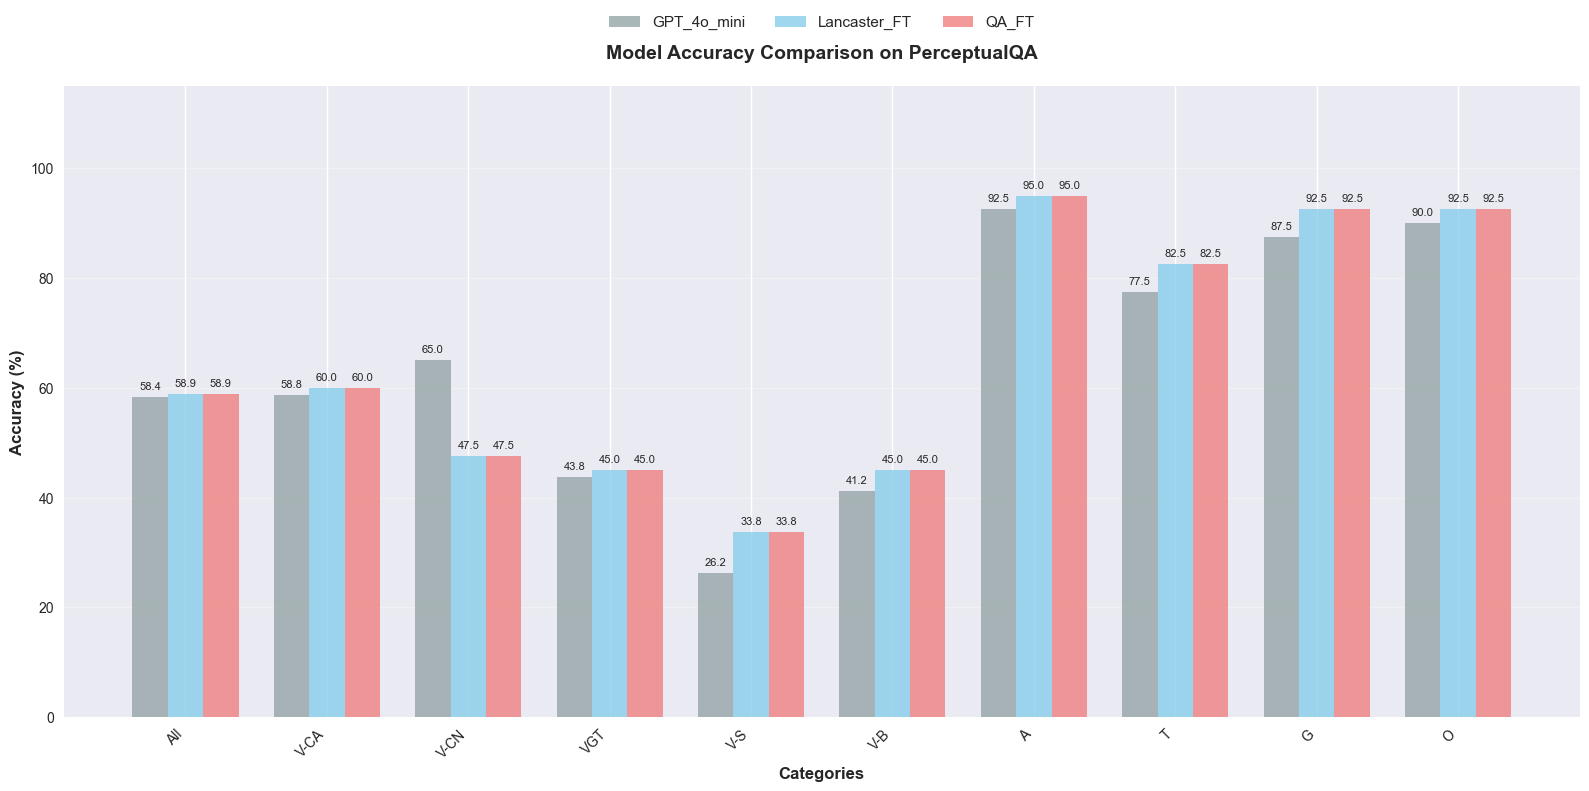

In [14]:
# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

# Data preparation
categories = [
    'All', 
    'V-CA', 
    'V-CN', 
    'VGT', 
    'V-S', 
    'V-B', 
    'A', 
    'T', 
    'G', 
    'O'
]

# Set chart size
fig, ax = plt.subplots(figsize=(16, 8))

# Set bar width
bar_width = 0.25

# Set X-axis position
index = np.arange(len(categories))

# Plot bars (Order adjusted to Base -> Lancaster -> QA_FT for comparison)
rects1 = ax.bar(index - bar_width, df_result_base, bar_width, label='GPT_4o_mini', color='#95a5a6', alpha=0.8)
rects2 = ax.bar(index, df_result_lancaster_ft, bar_width, label='Lancaster_FT', color='skyblue', alpha=0.8)
rects3 = ax.bar(index + bar_width, df_result_lancaster_ft, bar_width, label='QA_FT', color='lightcoral', alpha=0.8)

# Add labels and title
ax.set_xlabel('Categories', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Comparison on PerceptualQA', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(index)
ax.set_xticklabels(categories, rotation=45, ha='right')

# Legend placed at the top
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize=11, frameon=False)

# Add grid lines
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 115) # Set Y-axis range to leave space for labels

# Function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 1,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8, rotation=0)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# Study 3 Analysis (Lancaster test)
# ==========================================

results_dir = 'results'

# Define dimensions
dims_study3 = [
        'auditory', 'gustatory', 'haptic', 'interoceptive', 'olfactory', 'visual', 
        'foot_leg', 'hand_arm', 'head', 'mouth', 'torso'
    ]

# Define model dimension mapping
model_dim_map = {
    'foot_leg': 'foot',
    'hand_arm': 'hand'
}

# File paths
file_human = os.path.join(results_dir, '2_test_sensorimotor_random_sample.xlsx') # Assuming it contains English data

model_files = {
    'base': os.path.join(results_dir, '3_base_gpt_11_dimensions.xlsx'),
    'lancaster_ft': os.path.join(results_dir, '3_lancaster_model_11_dimensions.xlsx'),
    "QA_ft": os.path.join(results_dir, '3_QA_model_11_dimensions.xlsx'),
}

df_study3 = load_and_merge_files(file_human, model_files, join_col='Word')
    
model_patterns = {
        'base': "{dim}_English_gpt_base_base", 
        'lancaster_ft': "{dim}_gpt_all_ft_lancaster_ft",
        'QA_ft': "{dim}_gpt_QA_ft_QA_ft"
    }

results_study3 = calculate_similarities(
        df_study3,
        human_col_pattern="{dim}.mean_human", 
        model_col_patterns=model_patterns,
        dimensions=dims_study3,
        model_dim_mapping=model_dim_map
    )

print(results_study3)

Reading Human file: results/2_test_sensorimotor_random_sample.xlsx
Human data loaded, total 1572 rows. Example: ['unwilling', 'endless', 'networking']
Reading Model (base): results/3_base_gpt_11_dimensions.xlsx
  -> After merging with base: 1572 -> 1572 rows
Reading Model (lancaster_ft): results/3_lancaster_model_11_dimensions.xlsx
  -> After merging with lancaster_ft: 1572 -> 1572 rows
Reading Model (QA_ft): results/3_QA_model_11_dimensions.xlsx
  -> After merging with QA_ft: 1572 -> 1572 rows
Merge complete, final shape: (1572, 86)
       Dimension  base_Spearman  base_Spearman_p  base_Pearson  \
0       auditory       0.265728     9.100029e-27      0.274924   
1      gustatory       0.373891     4.873187e-53      0.536468   
2         haptic       0.437689     1.445813e-74      0.452750   
3  interoceptive       0.457352     4.338565e-82      0.452628   
4      olfactory       0.453923     4.350103e-80      0.618748   
5         visual       0.014707     5.618693e-01      0.033227  

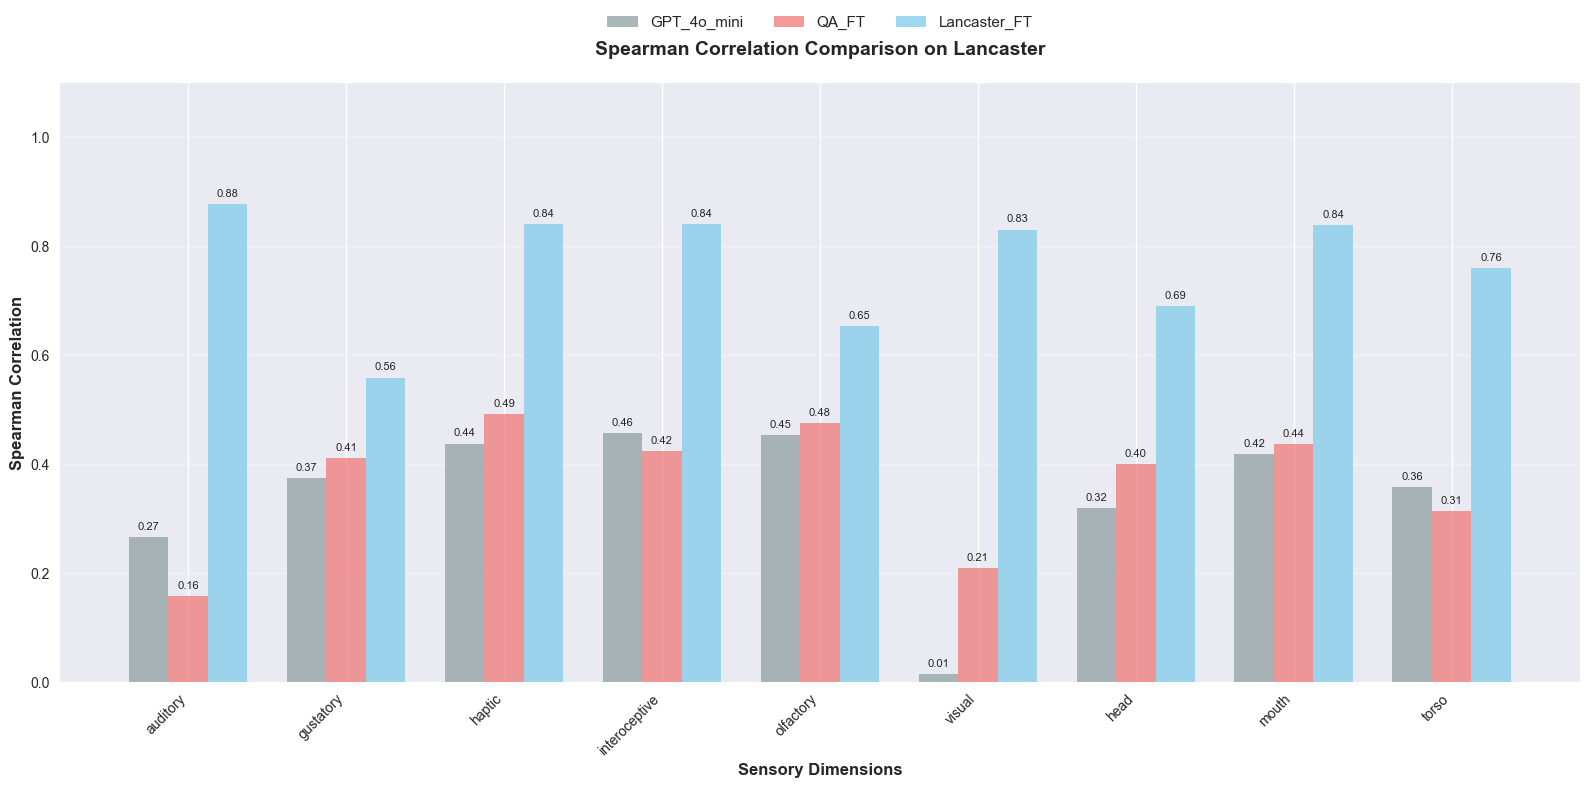

In [16]:
# New grouped bar chart: Spearman Correlation Comparison
import matplotlib.pyplot as plt
import numpy as np

# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

# Data preparation
categories_spearman = results_study3['Dimension']

# Data
lancaster_spearman = results_study3['lancaster_ft_Spearman'].tolist()
qa_ft_spearman = results_study3['QA_ft_Spearman'].tolist()
base_spearman = results_study3['base_Spearman'].tolist()

# Set chart size
fig, ax = plt.subplots(figsize=(16, 8))

# Set bar width
bar_width = 0.25

# Set X-axis position
index = np.arange(len(categories_spearman))

# Plot bars (Order adjusted to Base -> QA_FT -> Lancaster for comparison)
rects1 = ax.bar(index - bar_width, base_spearman, bar_width, label='GPT_4o_mini', color='#95a5a6', alpha=0.8)
rects2 = ax.bar(index, qa_ft_spearman, bar_width, label='QA_FT', color='lightcoral', alpha=0.8)
rects3 = ax.bar(index + bar_width, lancaster_spearman, bar_width, label='Lancaster_FT', color='skyblue', alpha=0.8)

# Add labels and title
ax.set_xlabel('Sensory Dimensions', fontsize=12, fontweight='bold')
ax.set_ylabel('Spearman Correlation', fontsize=12, fontweight='bold')
ax.set_title('Spearman Correlation Comparison on Lancaster', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(index)
ax.set_xticklabels(categories_spearman, rotation=45, ha='right')

# Legend placed at the top
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize=11, frameon=False)

# Add grid lines
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 1.1) # Set Y-axis range to leave space for labels

# Function to add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8, rotation=0)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()